# Train test — 1D Harmonic Oscillator

Ground truth: $E_0 = \frac{1}{2}\hbar\omega = 0.5$ (units $\hbar = m = 1$, $\omega = 1$).

Model: `mlp-fourth-decay`, which outputs $\log\psi = \text{MLP}(x) - \alpha\,x^4$ directly — a log-model with a Gaussian-like envelope that ensures decay at large $x$.

In [1]:
import sys
sys.path.insert(0, '../src')

import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt
import numpy as np

from qvarnet.train import train
from qvarnet.models.exponential import LogExponentialMLPwithPenalty
from qvarnet.hamiltonian.continuous import HarmonicOscillatorHamiltonian

## Setup

In [7]:
# System
N_PARTICLES = 10
DIM        = 1
N_CHAINS   = 5000
DoF        = N_PARTICLES * DIM
SHAPE      = (N_CHAINS, DoF)

# mlp-fourth-decay outputs log|ψ| directly
model = LogExponentialMLPwithPenalty(architecture=[DoF, 30, 1])
IS_LOG_MODEL = True

# Hamiltonian
hamiltonian = HarmonicOscillatorHamiltonian(omega=1.0)

# Optimizer
optimizer = optax.adam(learning_rate=1e-3)

# Sampler params
sampler_params = {
    "step_size": 0.5,
    "chain_length": 11,
    "thermalization_steps": 10,
    "thinning_factor": 1,
    "PBC": 40.0,
}

N_EPOCHS = 5000

## Train

In [8]:
history, cm_mean, cm_std = train(
    n_epochs=N_EPOCHS,
    shape=SHAPE,
    model=model,
    optimizer=optimizer,
    sampler_params=sampler_params,
    hamiltonian=hamiltonian,
    rng_seed=42,
    warm_walkers=False,
    is_update_step_size=True,
    is_log_model=IS_LOG_MODEL,
)

  0%|          | 0/5000 [00:00<?, ?it/s]

100%|██████████| 5000/5000 [02:50<00:00, 29.36it/s, E=5.01, sigma_E=0.13]


## Extract history

In [12]:
energies    = np.array([s.energy for s in history])/N_PARTICLES
stds        = np.array([s.std    for s in history])/N_PARTICLES
acc_rates   = np.array([float(jnp.mean(s.acceptance_rate)) for s in history])
step_sizes  = np.array([float(s.step_size) for s in history])
cm_mean_arr = np.array([float(x) for x in cm_mean])
cm_std_arr  = np.array([float(x) for x in cm_std])

steps   = np.arange(len(history))
E_EXACT = 0.5

## Plots

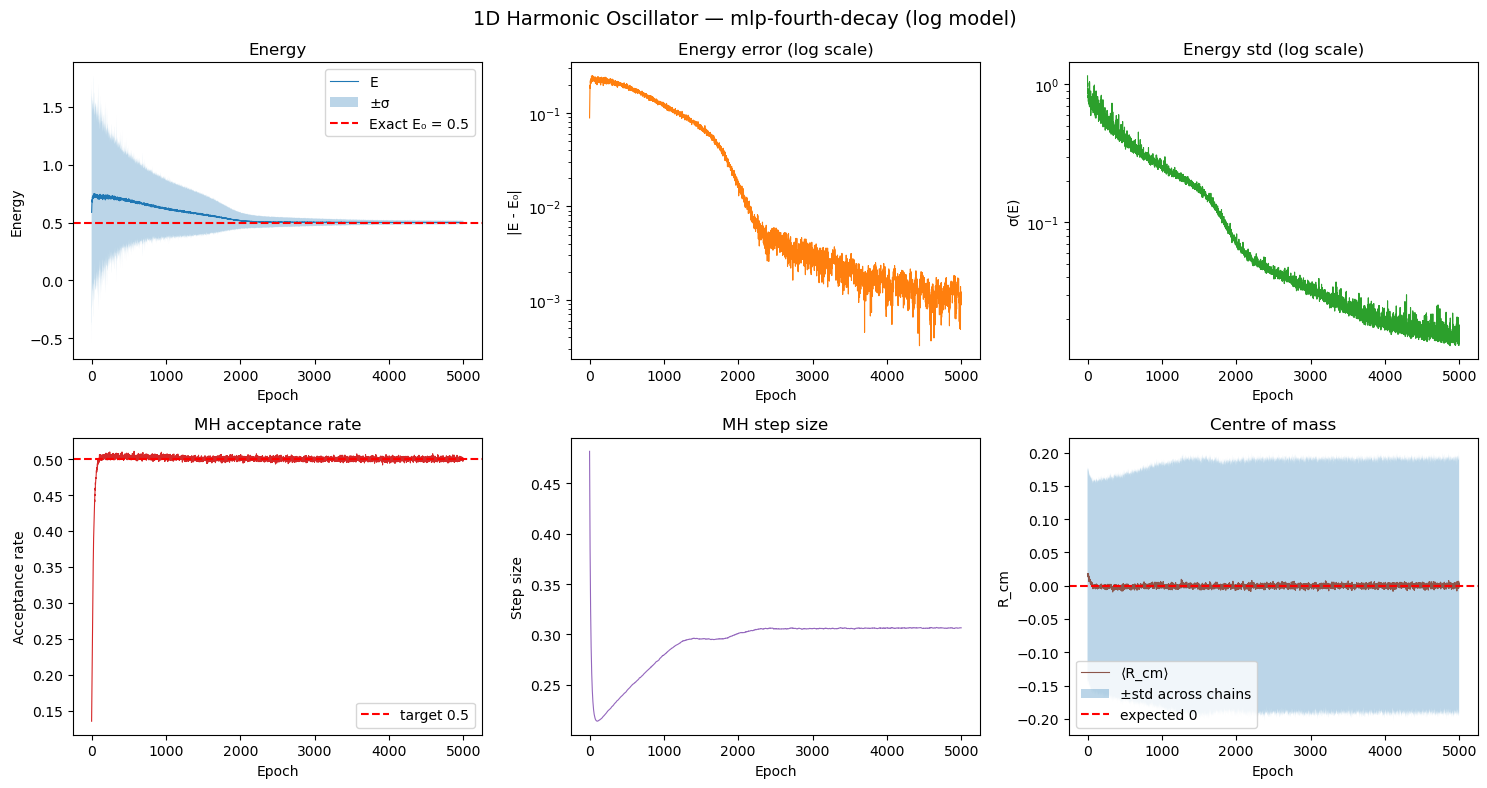

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('1D Harmonic Oscillator — mlp-fourth-decay (log model)', fontsize=14)

# --- Energy ---
ax = axes[0, 0]
ax.plot(steps, energies, lw=0.8, label='E')
ax.fill_between(steps, energies - stds, energies + stds, alpha=0.3, label='±σ')
ax.axhline(E_EXACT, color='red', ls='--', label=f'Exact E₀ = {E_EXACT}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Energy')
ax.set_title('Energy')
ax.legend()

# --- Energy error ---
ax = axes[0, 1]
ax.semilogy(steps, np.abs(energies - E_EXACT), lw=0.8, color='C1')
ax.set_xlabel('Epoch')
ax.set_ylabel('|E - E₀|')
ax.set_title('Energy error (log scale)')

# --- Std ---
ax = axes[0, 2]
ax.semilogy(steps, stds, lw=0.8, color='C2')
ax.set_xlabel('Epoch')
ax.set_ylabel('σ(E)')
ax.set_title('Energy std (log scale)')

# --- Acceptance rate ---
ax = axes[1, 0]
ax.plot(steps, acc_rates, lw=0.8, color='C3')
ax.axhline(0.5, color='red', ls='--', label='target 0.5')
ax.set_xlabel('Epoch')
ax.set_ylabel('Acceptance rate')
ax.set_title('MH acceptance rate')
ax.legend()

# --- Step size ---
ax = axes[1, 1]
ax.plot(steps, step_sizes, lw=0.8, color='C4')
ax.set_xlabel('Epoch')
ax.set_ylabel('Step size')
ax.set_title('MH step size')

# --- Centre of mass ---
ax = axes[1, 2]
ax.plot(steps, cm_mean_arr, lw=0.8, color='C5', label='⟨R_cm⟩')
ax.fill_between(steps,
                cm_mean_arr - cm_std_arr,
                cm_mean_arr + cm_std_arr,
                alpha=0.3, label='±std across chains')
ax.axhline(0.0, color='red', ls='--', label='expected 0')
ax.set_xlabel('Epoch')
ax.set_ylabel('R_cm')
ax.set_title('Centre of mass')
ax.legend()

plt.tight_layout()
plt.savefig('train_test_results.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

In [11]:
final_E   = energies[-20:].mean()
final_std = stds[-20:].mean()
error     = abs(final_E - E_EXACT)

print(f"Exact E₀           : {E_EXACT:.6f}")
print(f"Final E (last 20)  : {final_E:.6f} ± {final_std:.6f}")
print(f"|E - E₀|           : {error:.6f}")
print(f"Relative error     : {error/E_EXACT * 100:.3f}%")
print(f"Final accept rate  : {acc_rates[-20:].mean():.3f}")
print(f"Final step size    : {step_sizes[-1]:.4f}")
print(f"Final ⟨R_cm⟩       : {cm_mean_arr[-20:].mean():.4f}")
print(f"Final std(R_cm)    : {cm_std_arr[-20:].mean():.4f}")

Exact E₀           : 0.500000
Final E (last 20)  : 5.009414 ± 0.151264
|E - E₀|           : 4.509414
Relative error     : 901.883%
Final accept rate  : 0.500
Final step size    : 0.3066
Final ⟨R_cm⟩       : 0.0001
Final std(R_cm)    : 0.1917
